# Telecom Customer Churn Prediction

In this notebook I am building a churn prediction workflow using Logistic Regression, Random Forest, and XGBoost. The goal is to understand which customers are likely to leave and compare model performance clearly.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT / "src"))

from data_preprocessing import build_preprocessor, prepare_dataframe, split_features_target

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load and Prepare Data

In [2]:
df = prepare_dataframe()
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,is_new_customer,avg_charge_per_month,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,29.850000,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,0,55.573529,4
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,54.075000,4
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,40.905556,4
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,75.825000,2


In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n")
print(df.isna().sum().sort_values(ascending=False).head(15))

Shape: (7043, 23)

Missing values:

TotalCharges        11
SeniorCitizen        0
gender               0
Dependents           0
tenure               0
PhoneService         0
Partner              0
MultipleLines        0
InternetService      0
OnlineBackup         0
OnlineSecurity       0
TechSupport          0
StreamingTV          0
StreamingMovies      0
DeviceProtection     0
dtype: int64


## Quick Exploration

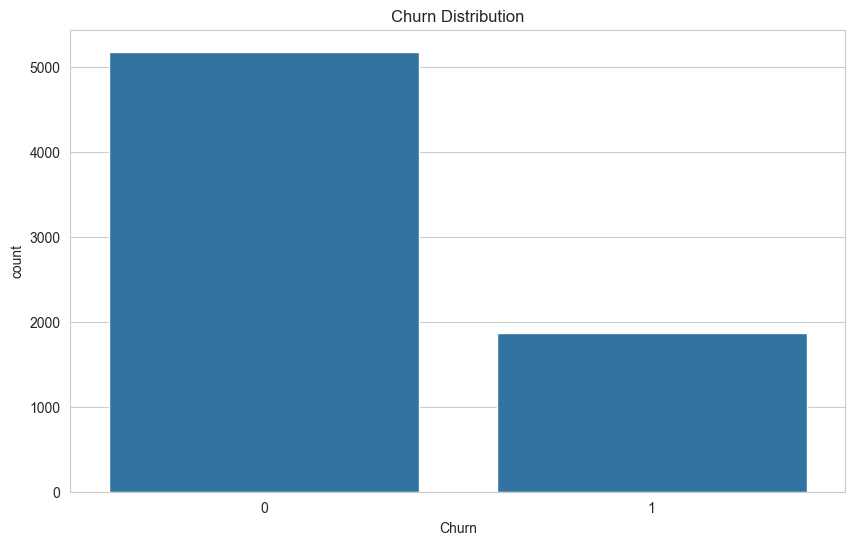

In [4]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

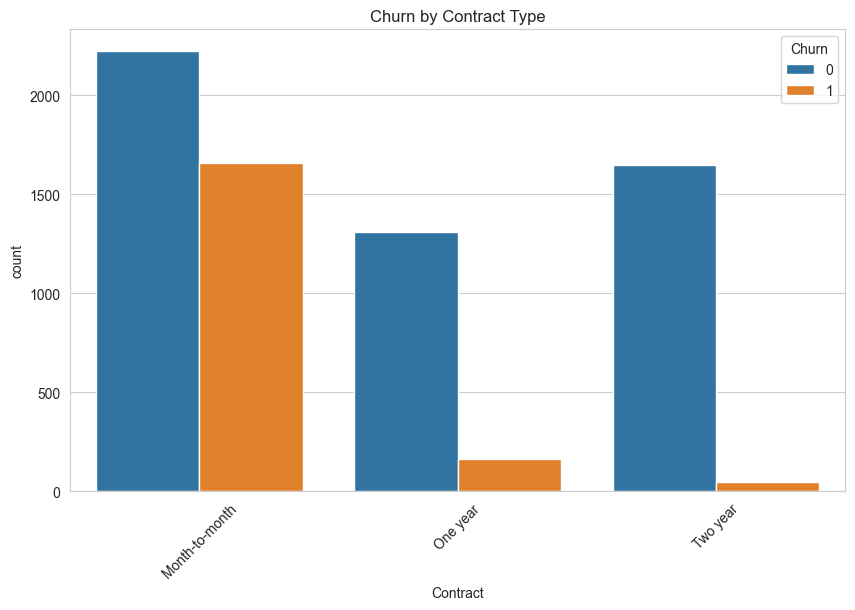

In [5]:
if "Contract" in df.columns:
    sns.countplot(data=df, x="Contract", hue="Churn")
    plt.title("Churn by Contract Type")
    plt.xticks(rotation=45)
    plt.show()

## Train and Compare Models

In [6]:
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocessor = build_preprocessor(X)

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=250, max_depth=8, min_samples_split=5, class_weight="balanced", random_state=42)),
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
rows = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "CV ROC-AUC": round(cv_scores.mean(), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "Test ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(rows).sort_values("Test ROC-AUC", ascending=False)
results_df

,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,Test ROC-AUC
2,XGBoost,0.8451,0.7977,0.6478,0.5214,0.5778,0.8435
1,Random Forest,0.8467,0.7644,0.5396,0.7647,0.6327,0.8430
0,Logistic Regression,0.8458,0.7367,0.5026,0.7888,0.6139,0.8414


## Check Best Model

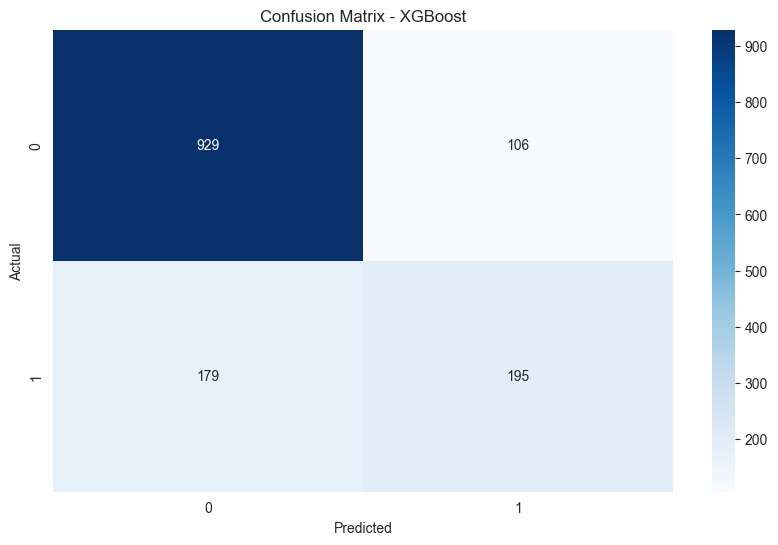

In [8]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

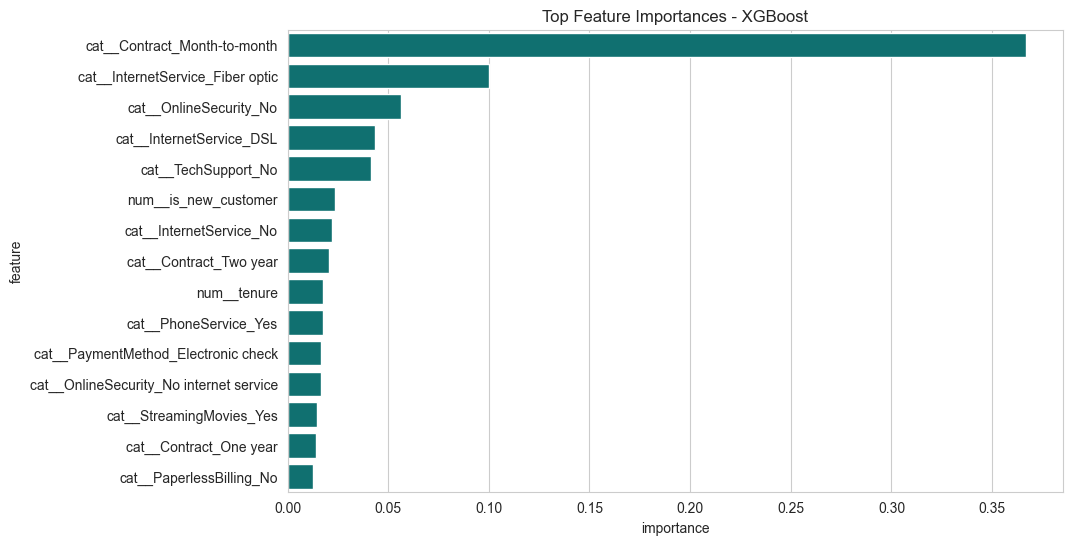

In [9]:
fitted_model = best_model.named_steps["model"]
fitted_preprocessor = best_model.named_steps["preprocessor"]

if hasattr(fitted_model, "feature_importances_"):
    feature_names = fitted_preprocessor.get_feature_names_out()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    sns.barplot(data=importance_df, x="importance", y="feature", color="teal")
    plt.title(f"Top Feature Importances - {best_name}")
    plt.show()
else:
    print("This model does not expose feature_importances_. Try Random Forest or XGBoost.")

## Notes

- Put the CSV file in `data/raw/telecom_churn.csv`
- Run the notebook from top to bottom
- You can also use `python src/train_models.py` to generate saved outputs automatically

## Automated Model Comparison Dashboard

This section loads all supervised and unsupervised outputs generated by `src/train_models.py`, including:
- Logistic Regression, Random Forest, XGBoost metrics
- Threshold-tuned classification metrics
- Probability diagnostics (MSE, RMSE, MAE, R2, log loss, Brier score)
- KMeans clustering metrics (silhouette, inertia, Davies-Bouldin, Calinski-Harabasz)
- Plot gallery for direct visual comparison

Project root: C:\Users\ismai\OneDrive\Desktop\Telecom_Churn_Prediction
Outputs directory exists: True

Supervised model metrics


,Model,Tuning_CV_ROC_AUC,Best_Params,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Best_Threshold,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,...,Test_Precision_Tuned,Test_Recall_Tuned,Test_F1_Tuned,Test_ROC_AUC,Test_Log_Loss,Test_Brier_Score,Test_MSE_Prob,Test_RMSE_Prob,Test_MAE_Prob,Test_R2_Prob
0,XGBoost,0.8455,{'model__colsample_bytree': np.float64(0.80767...,0.8480,0.0115,0.34,0.8070,0.6759,0.5241,0.5904,...,0.5526,0.7299,0.6290,0.8463,0.4146,0.1351,0.1351,0.3676,0.2662,0.3070
1,Random Forest,0.8491,"{'model__max_depth': 9, 'model__max_features':...",0.8473,0.0086,0.57,0.7608,0.5347,0.7620,0.6284,...,0.5670,0.6791,0.6180,0.8427,0.4682,0.1561,0.1561,0.3951,0.3119,0.1994
2,Logistic Regression,0.8482,"{'model__C': np.float64(3.590362888980227), 'm...",0.8458,0.0116,0.61,0.7353,0.5009,0.7861,0.6119,...,0.5516,0.7005,0.6172,0.8407,0.4968,0.1679,0.1679,0.4098,0.3193,0.1388



Supervised vs unsupervised


,Technique,Score
0,Best Supervised (ROC-AUC),0.846300
1,Best Unsupervised (Silhouette),0.244625



Unsupervised clustering metrics


,k,silhouette_score,inertia,davies_bouldin,calinski_harabasz
0,2,0.214726,82409.864766,1.749139,2262.667826
1,3,0.244625,64910.711615,1.596642,2385.081678
2,4,0.211148,59223.721056,1.901429,1967.794161
3,5,0.212964,55506.885890,1.811621,1692.266141
4,6,0.188890,52685.622993,1.729631,1501.471219
5,7,0.179051,50012.730126,1.810720,1380.582160
6,8,0.169419,47896.518588,1.883893,1279.867763



Cluster churn summary


,Cluster,churn_rate,customers
0,1,0.443948,2908
1,2,0.178229,2609
2,0,0.074050,1526



Plot Gallery

supervised_model_comparison.png


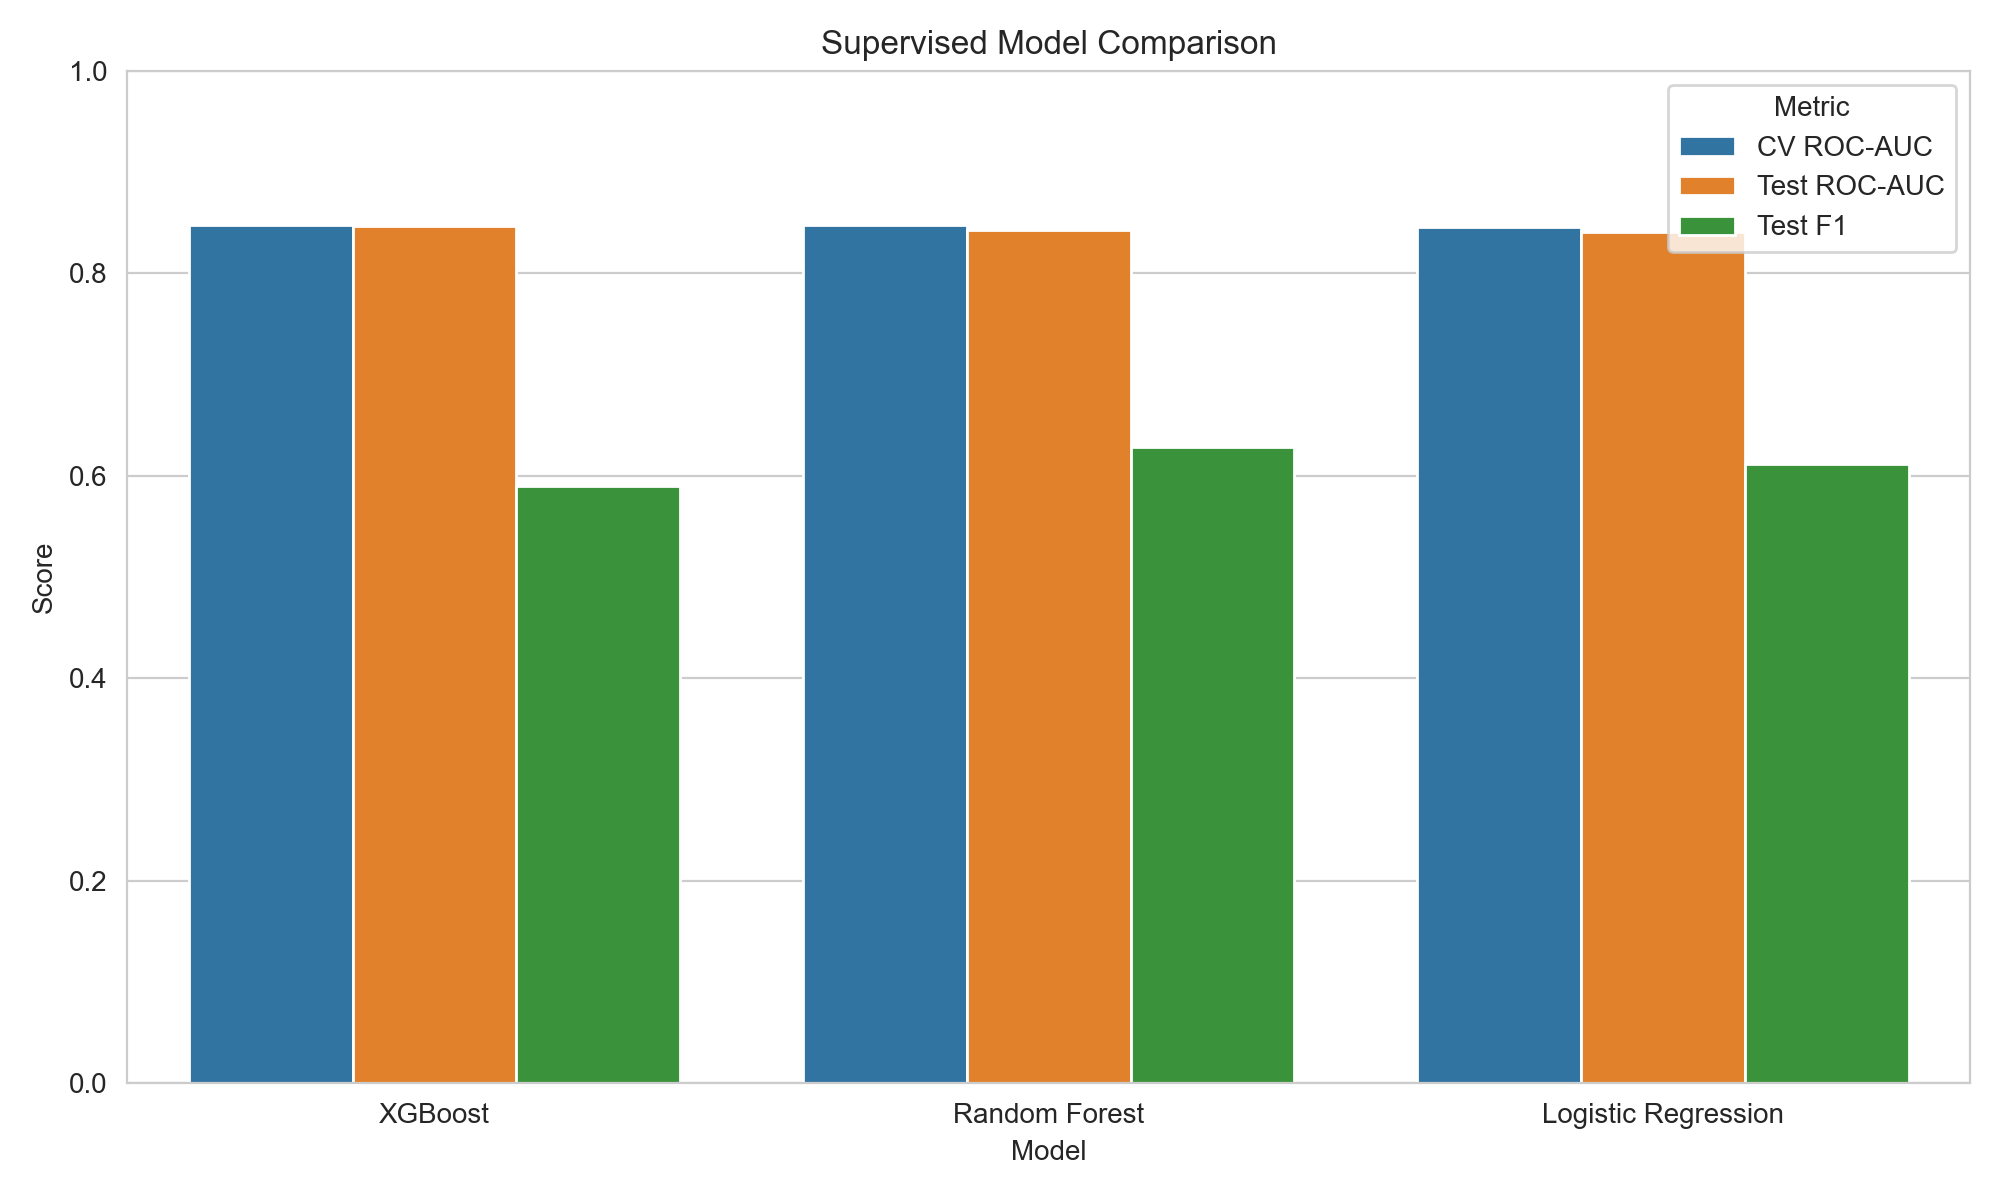


roc_curves_all_models.png


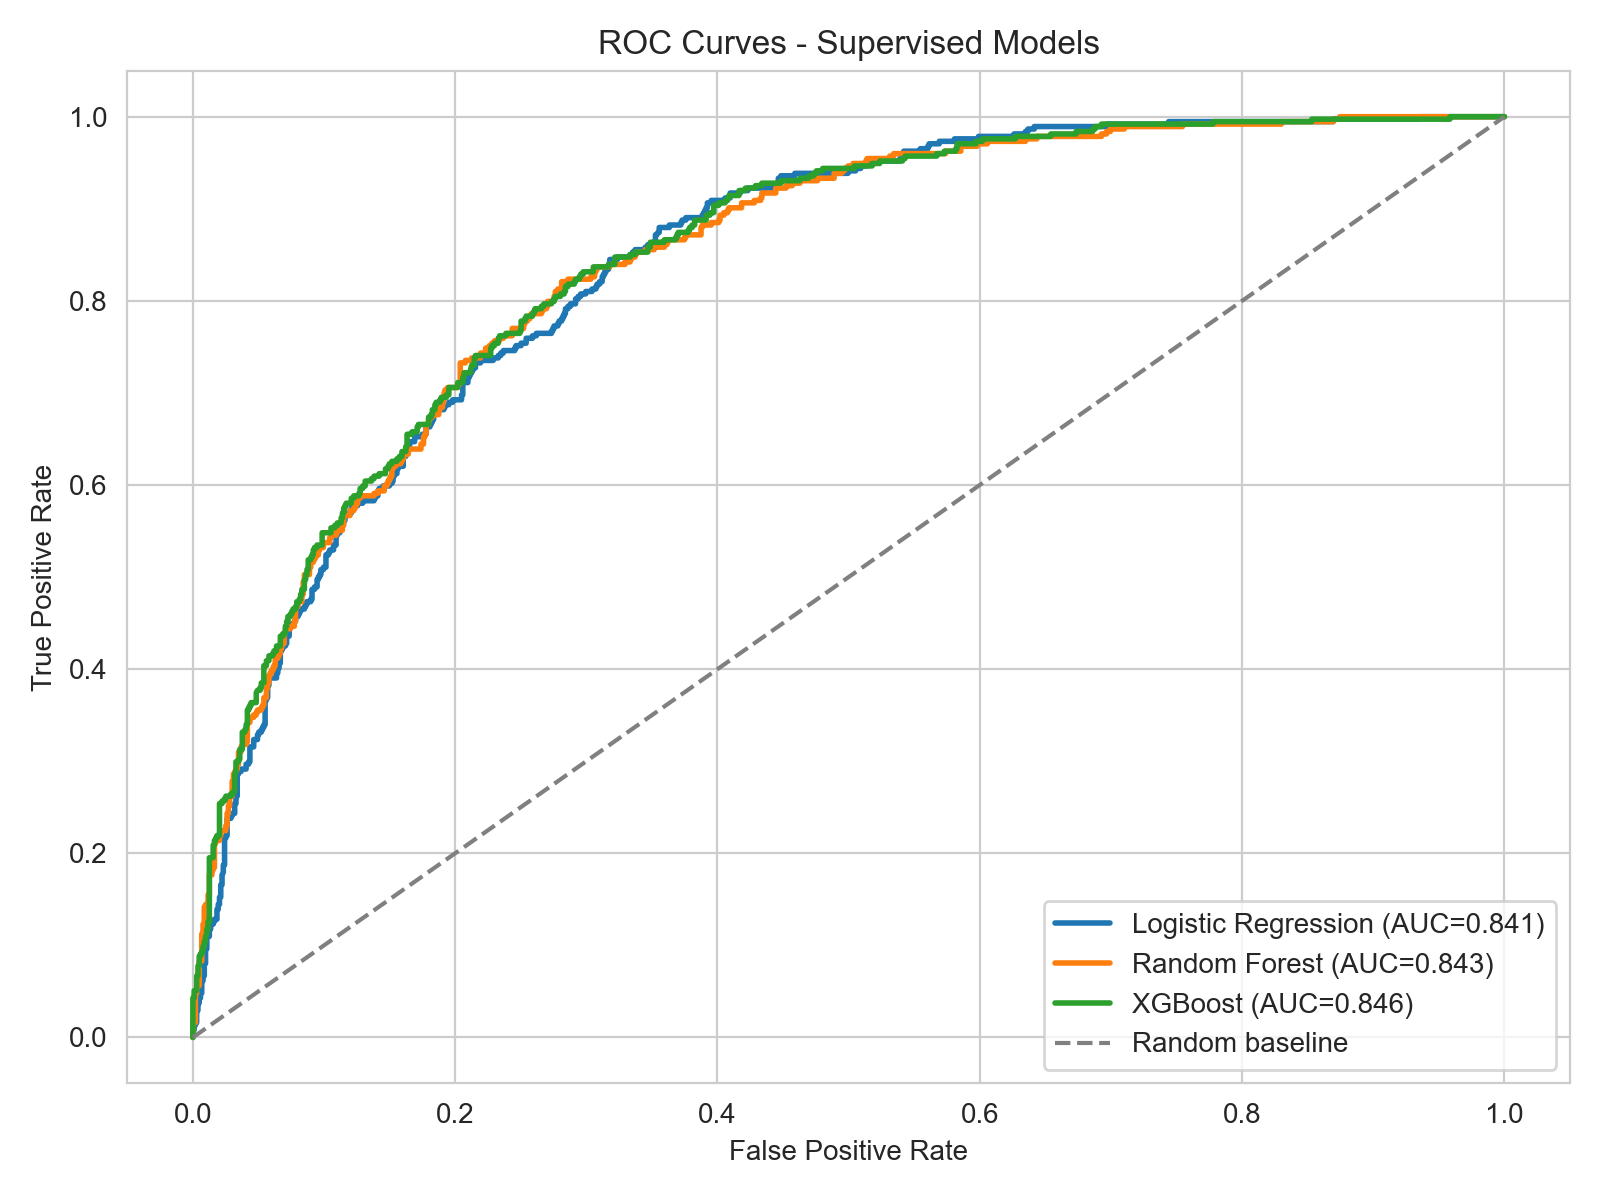


precision_recall_curves_all_models.png


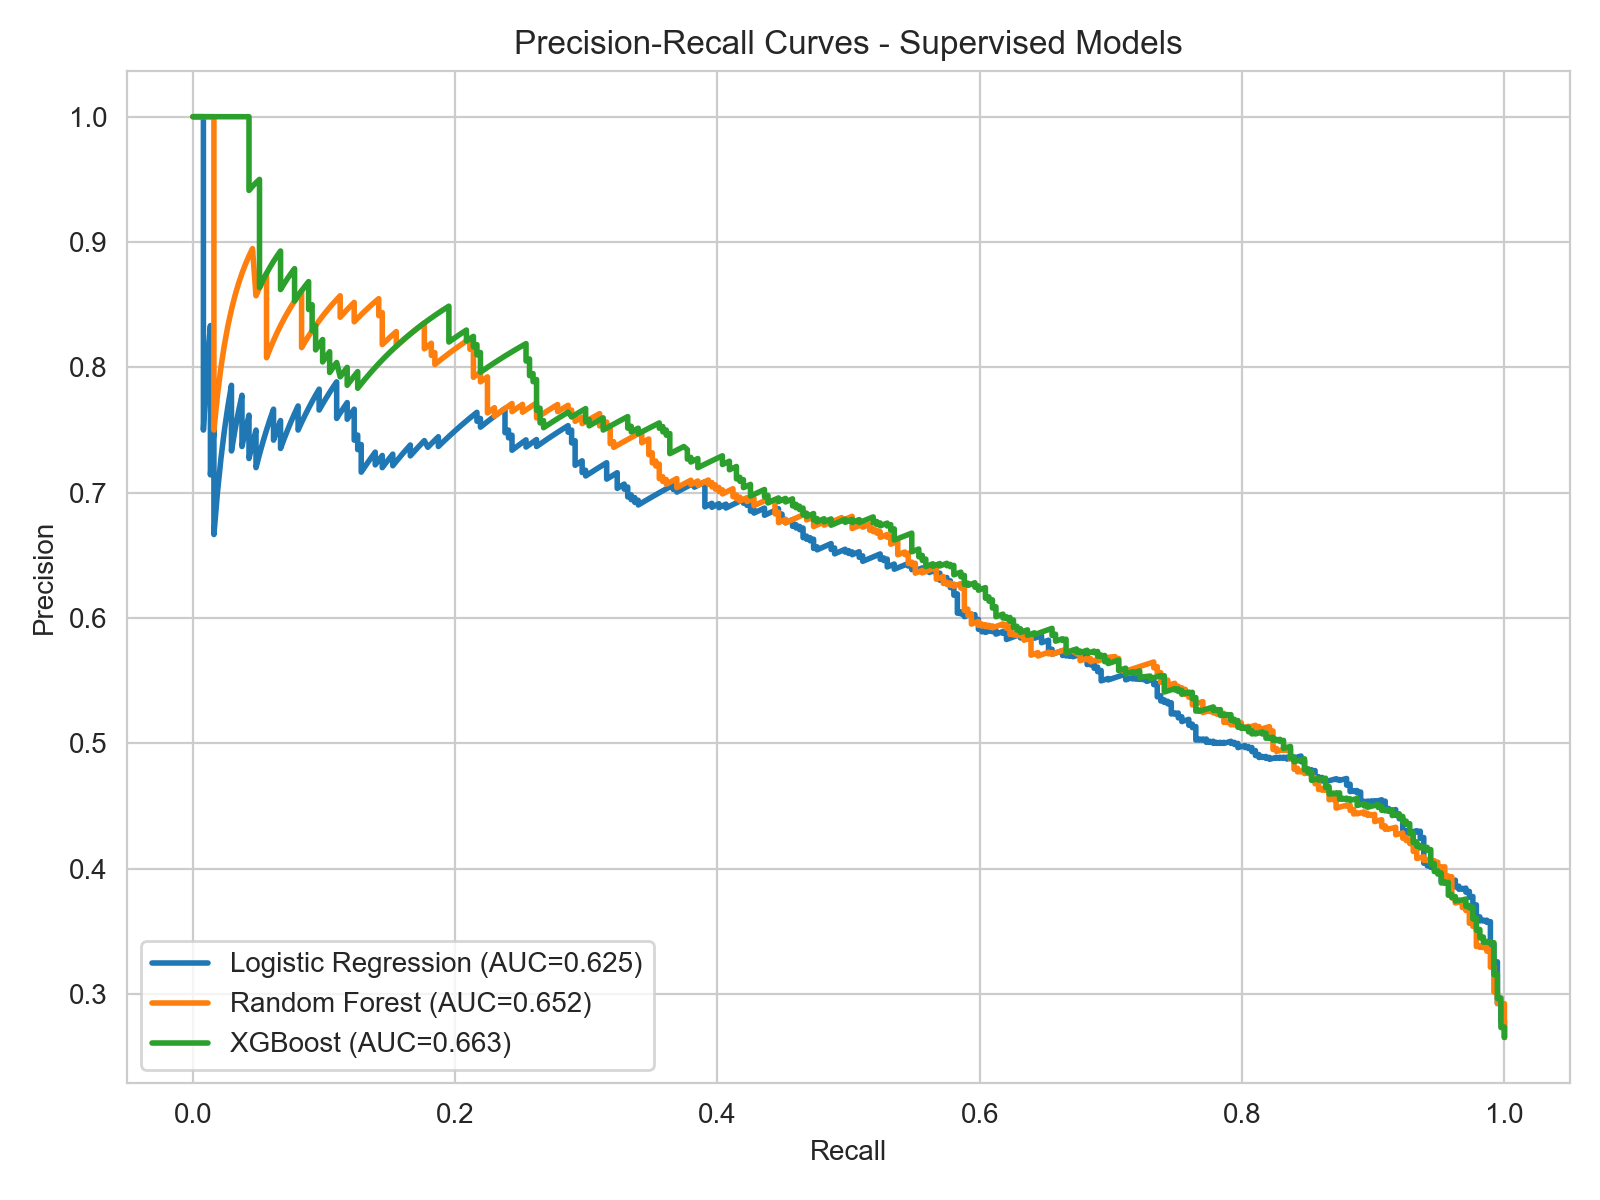


threshold_tuning_f1_comparison.png


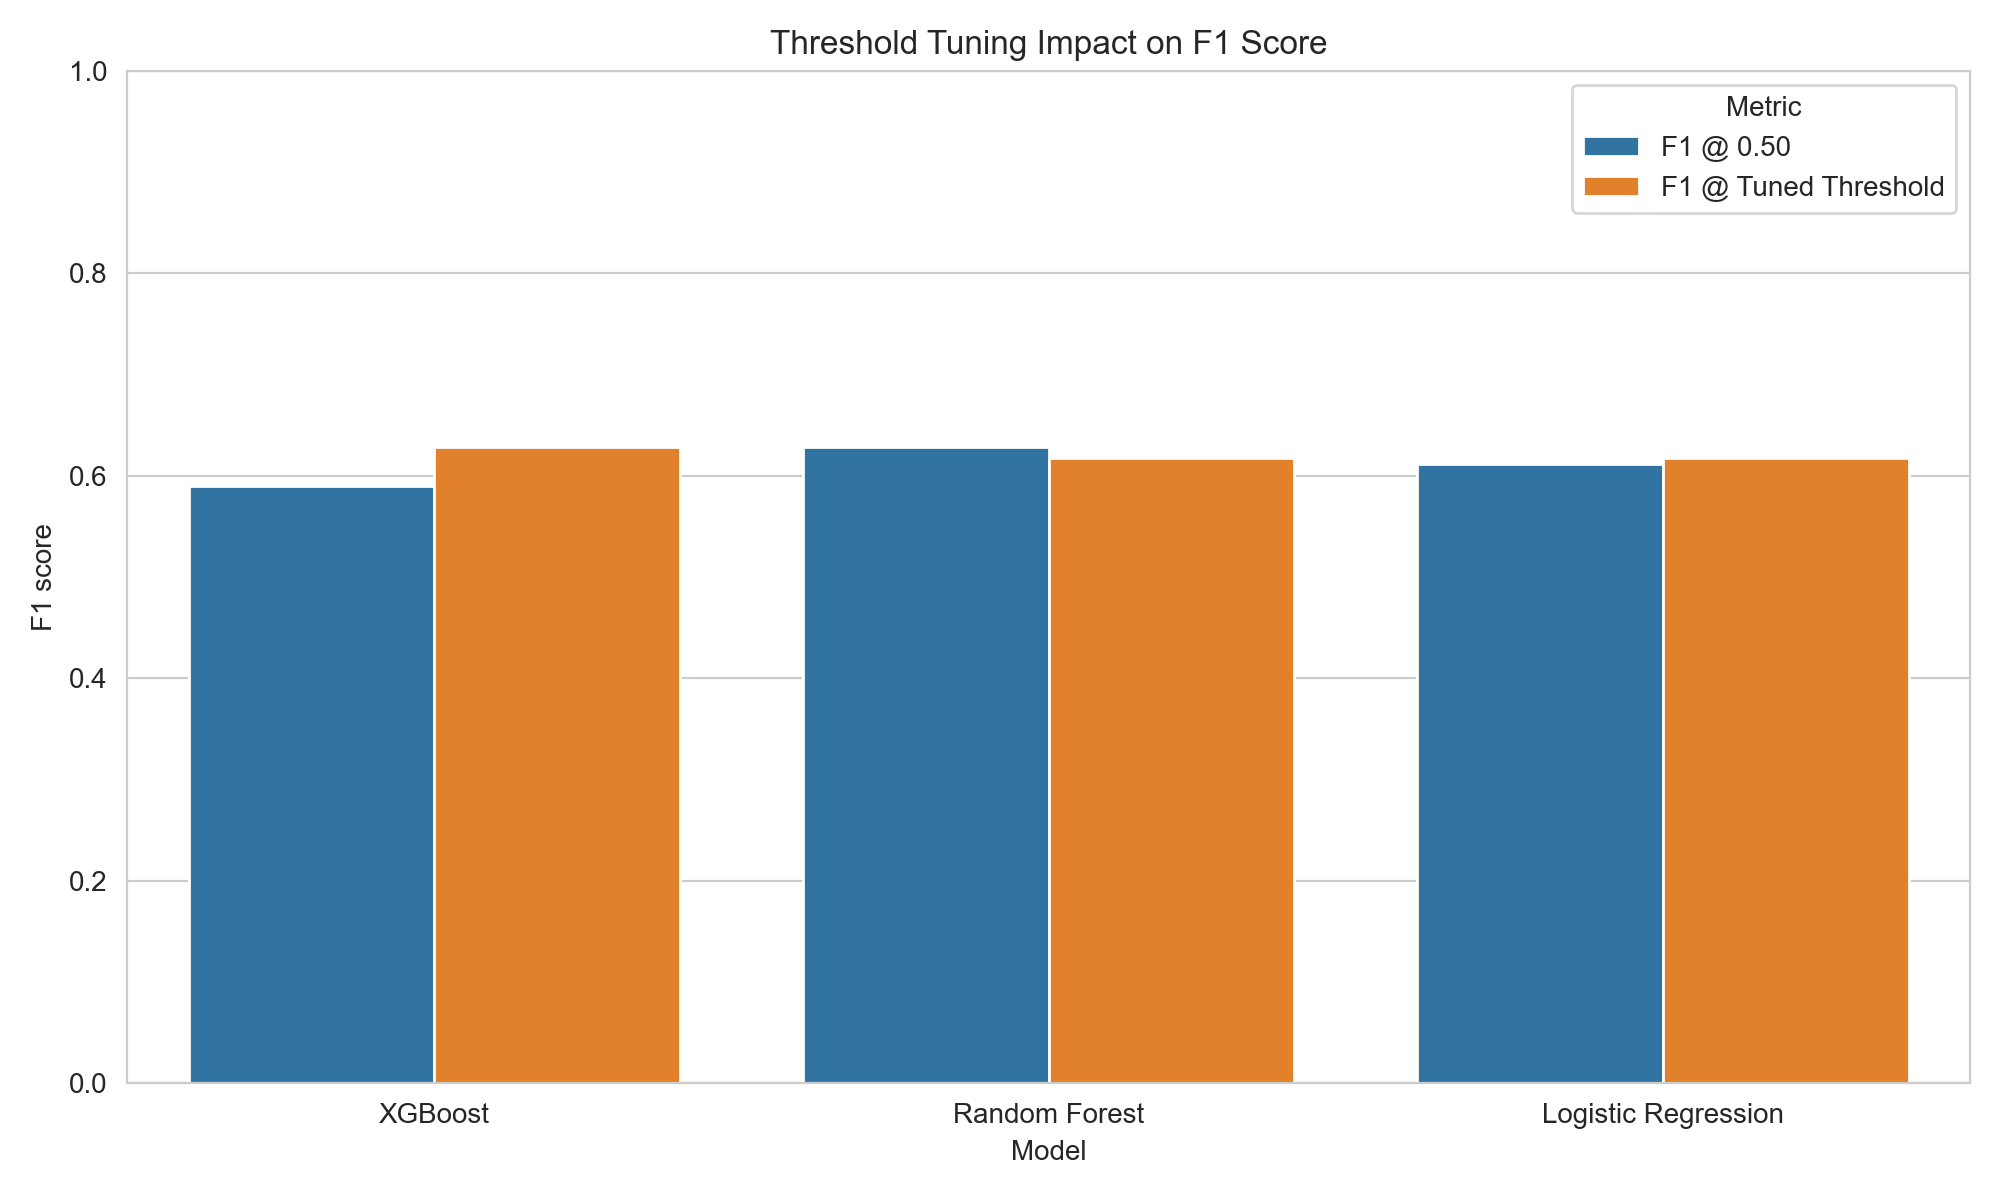


confusion_matrix_best_model.png


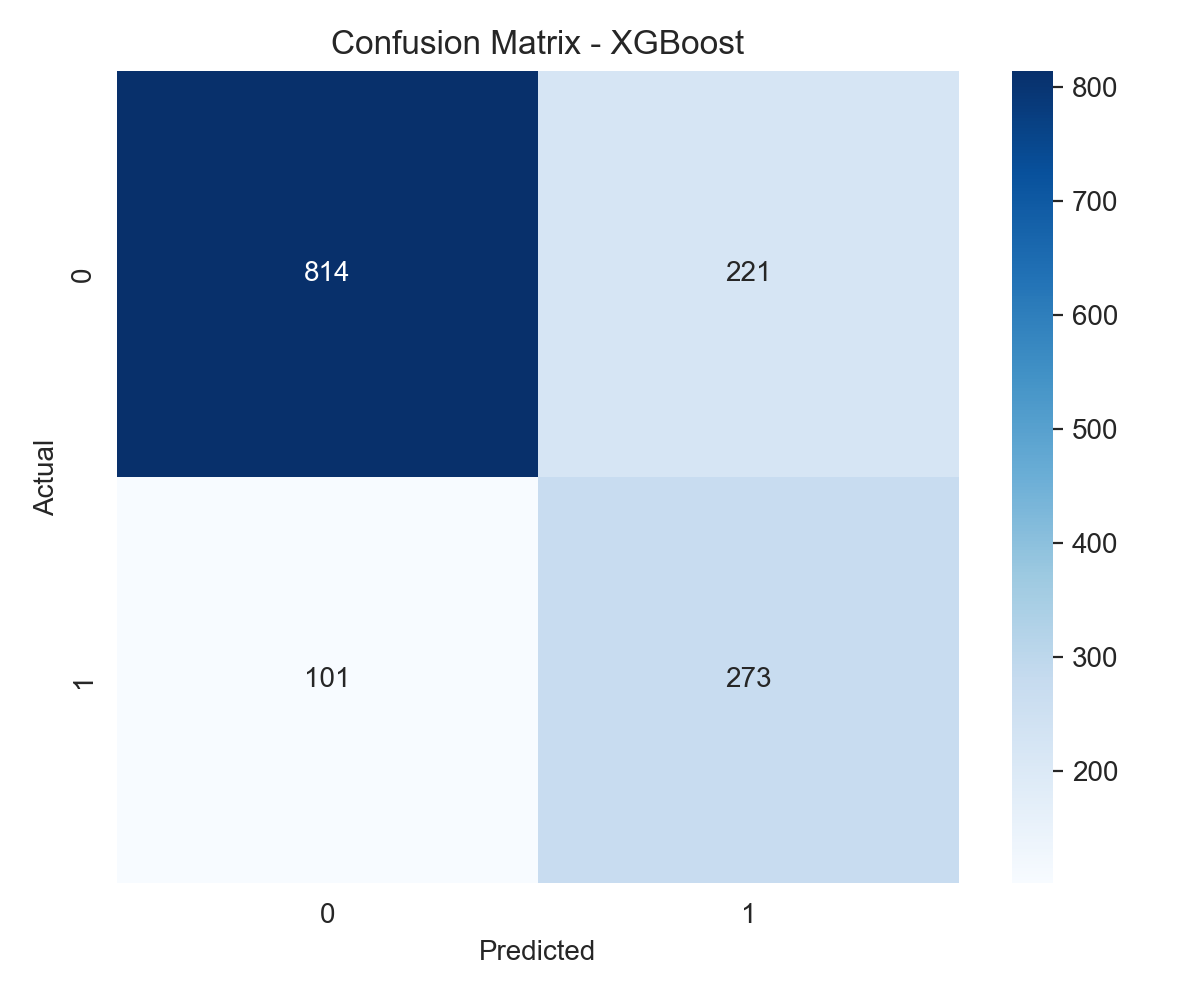


feature_importance_best_model.png


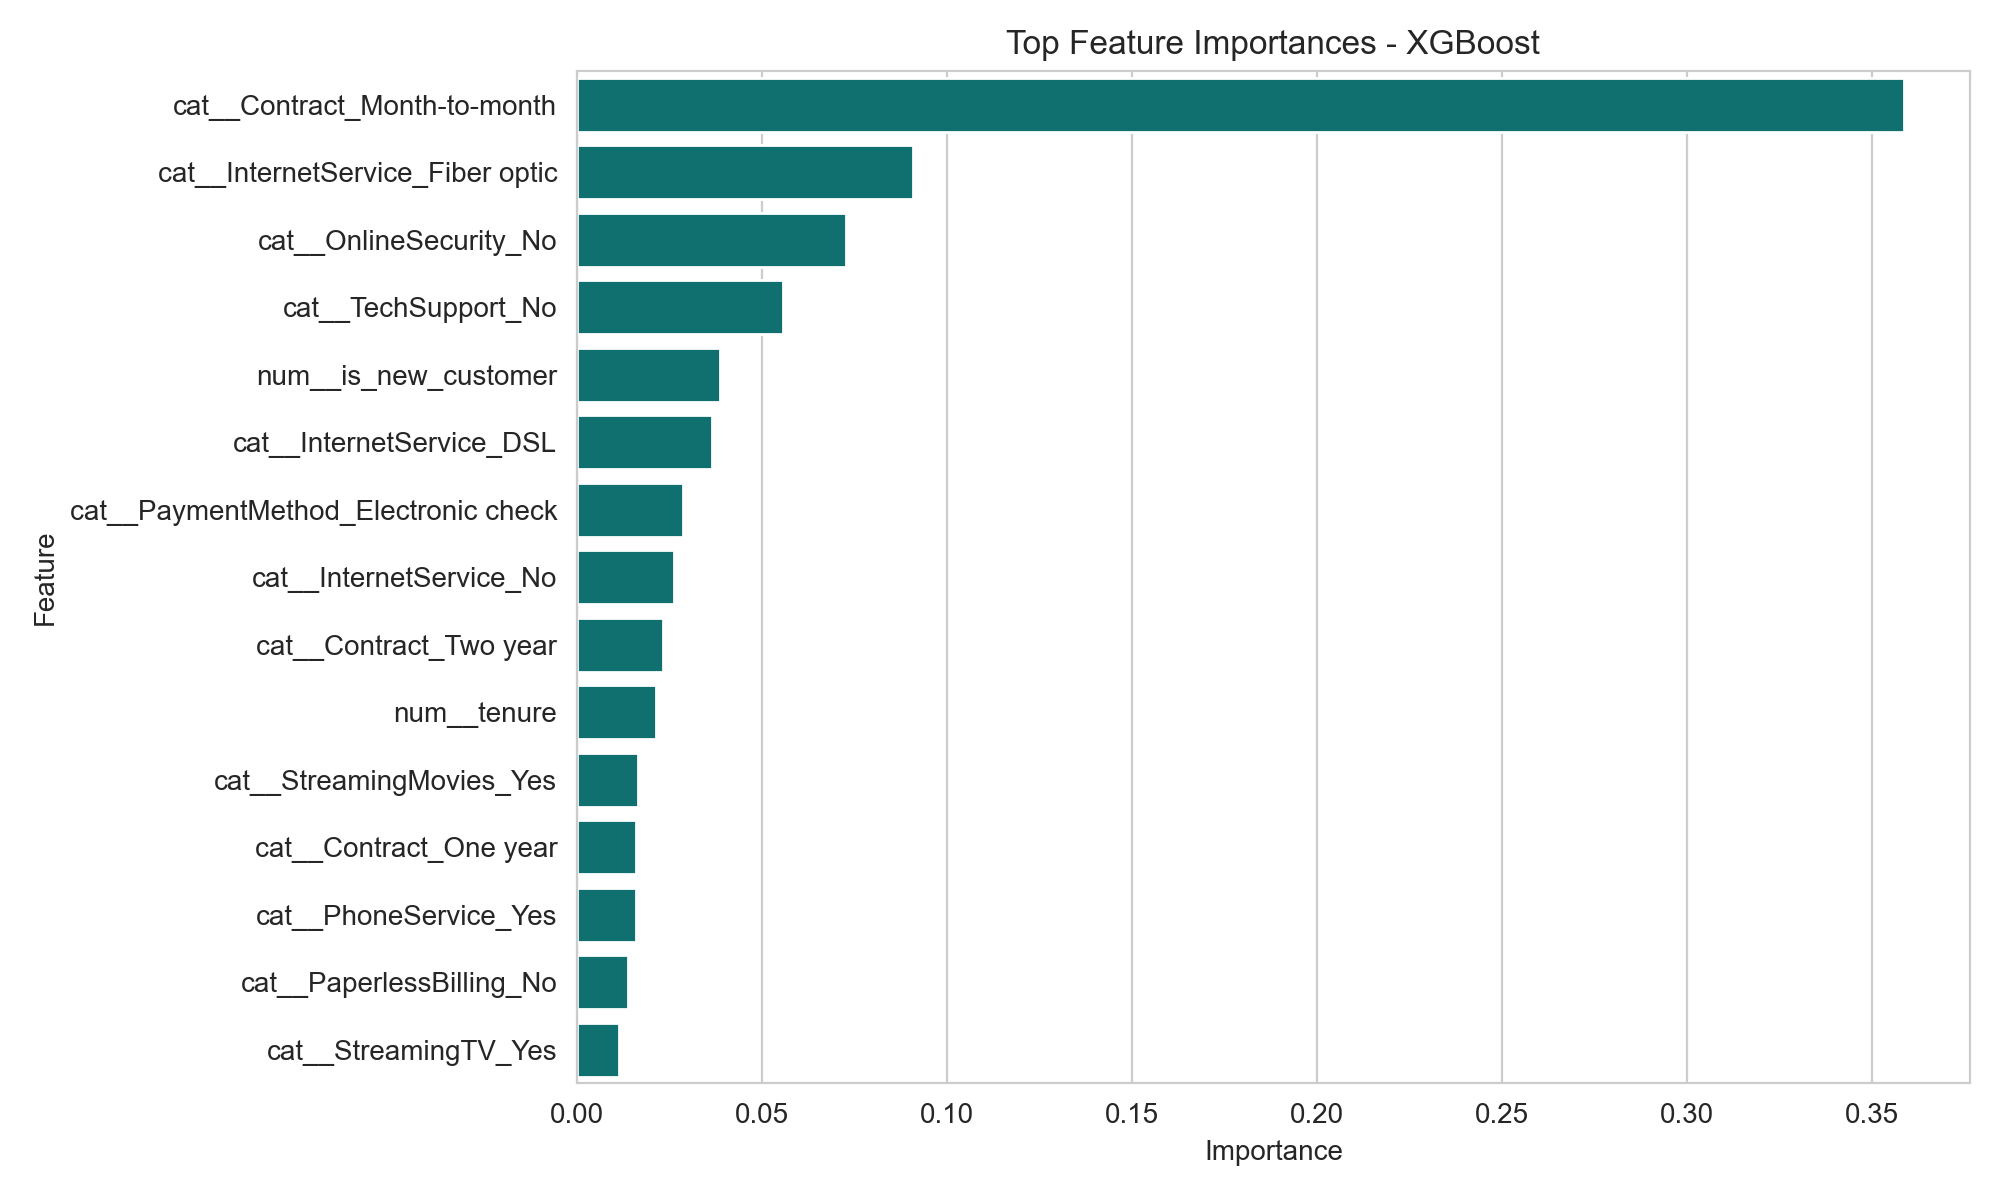


unsupervised_silhouette_scores.png


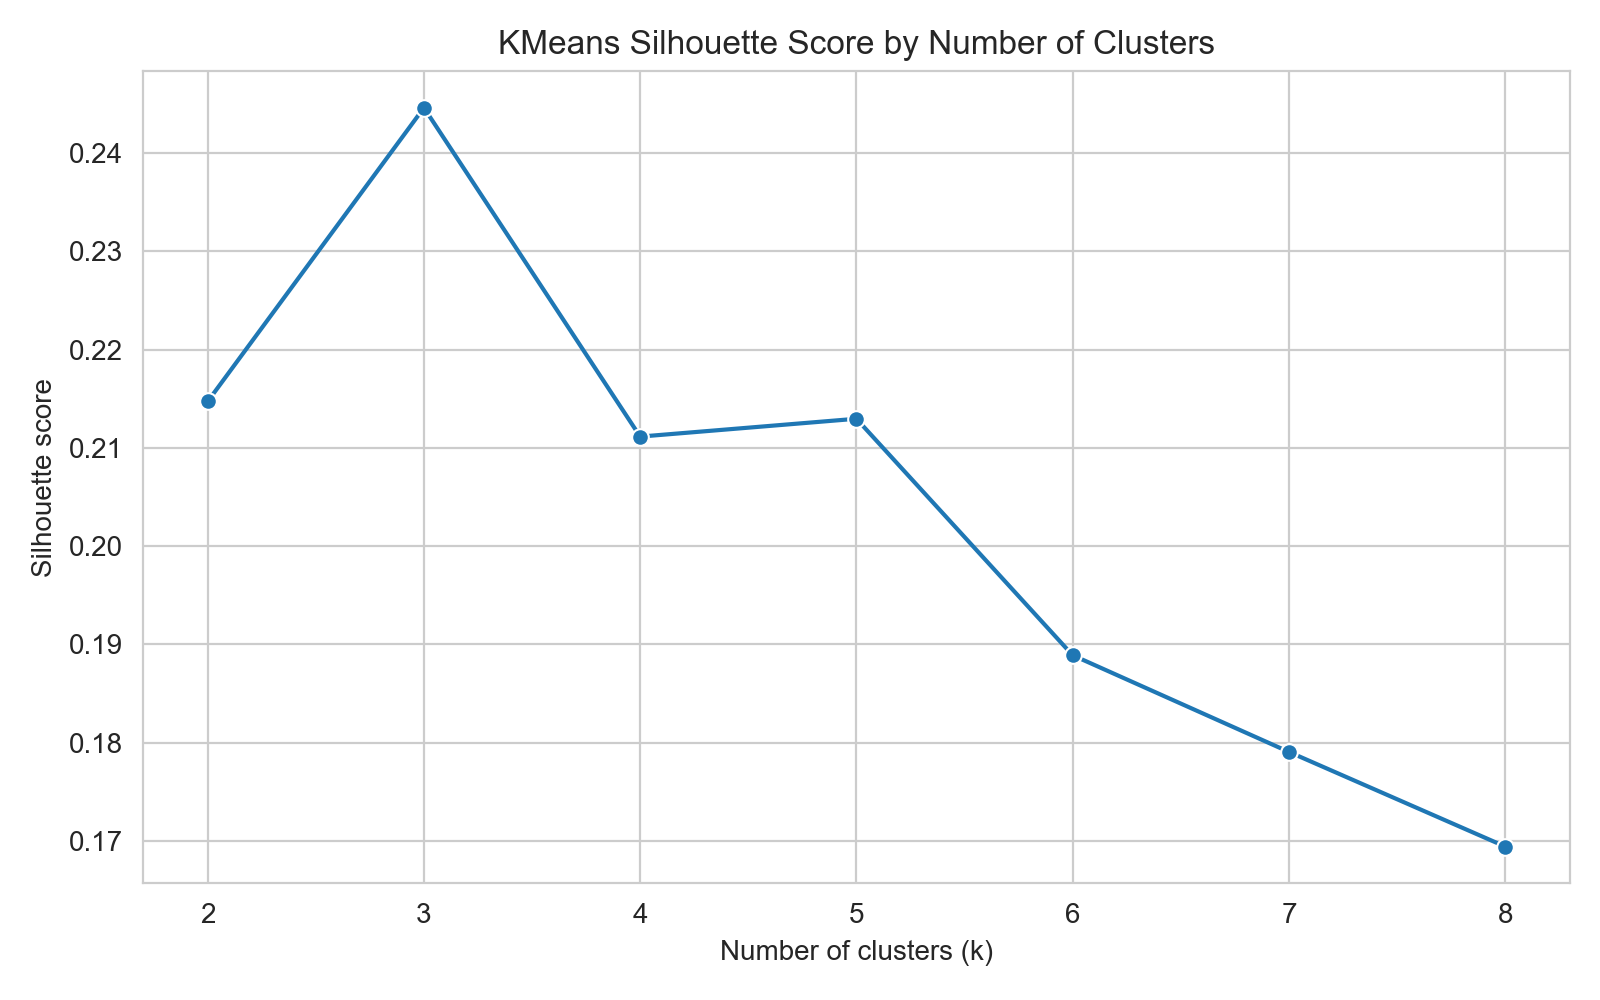


unsupervised_elbow_curve.png


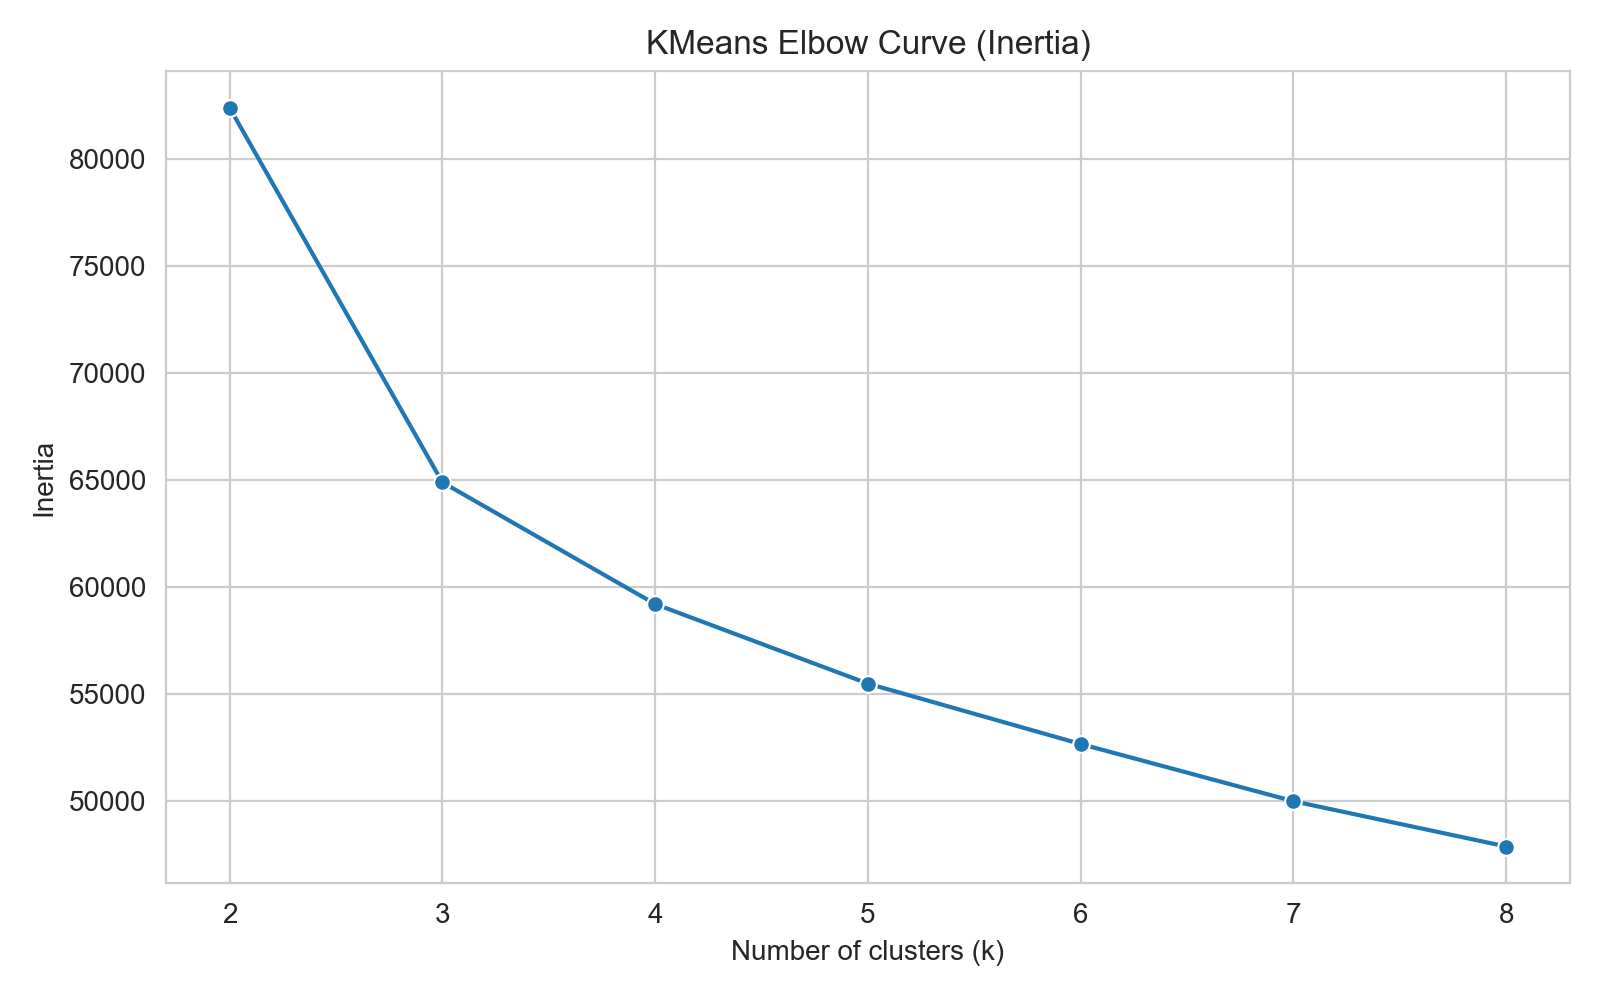


unsupervised_clusters_projection.png


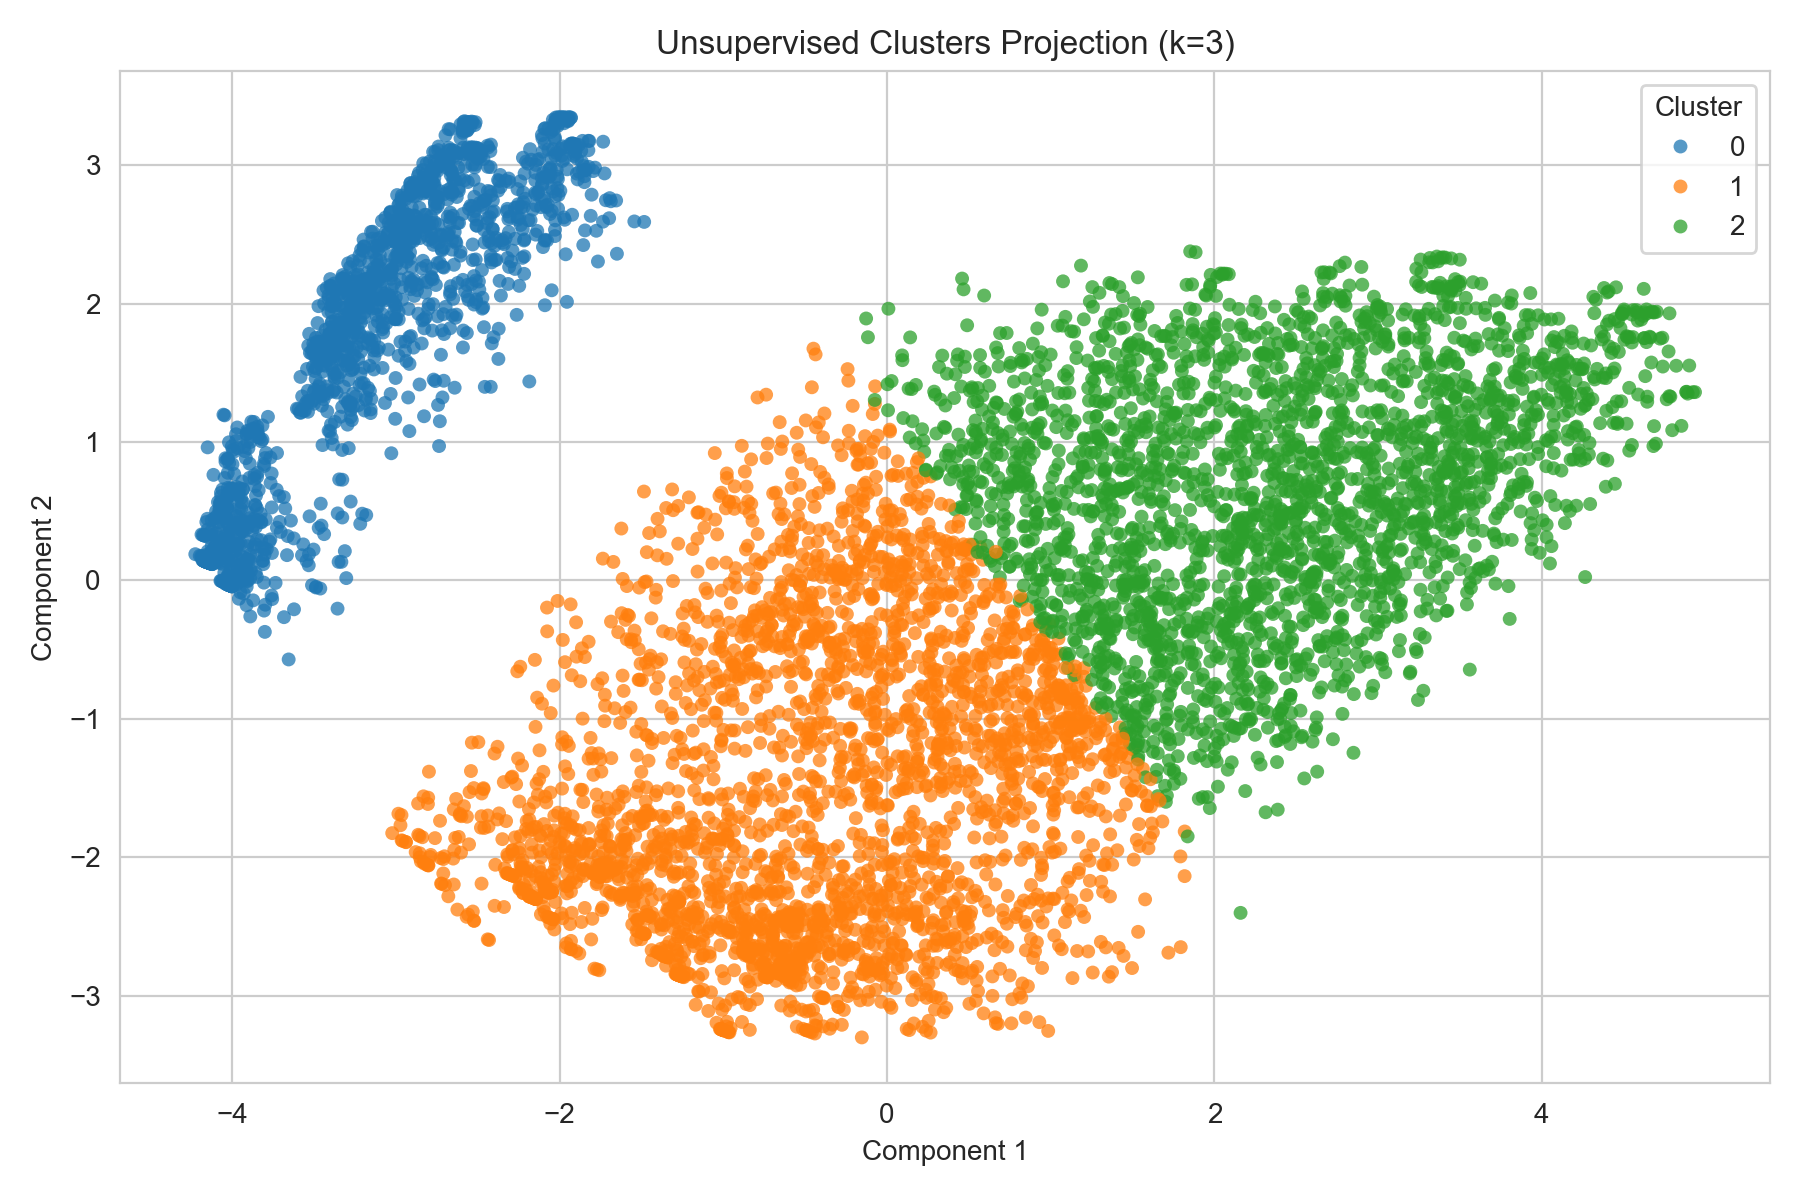


unsupervised_cluster_churn_rate.png


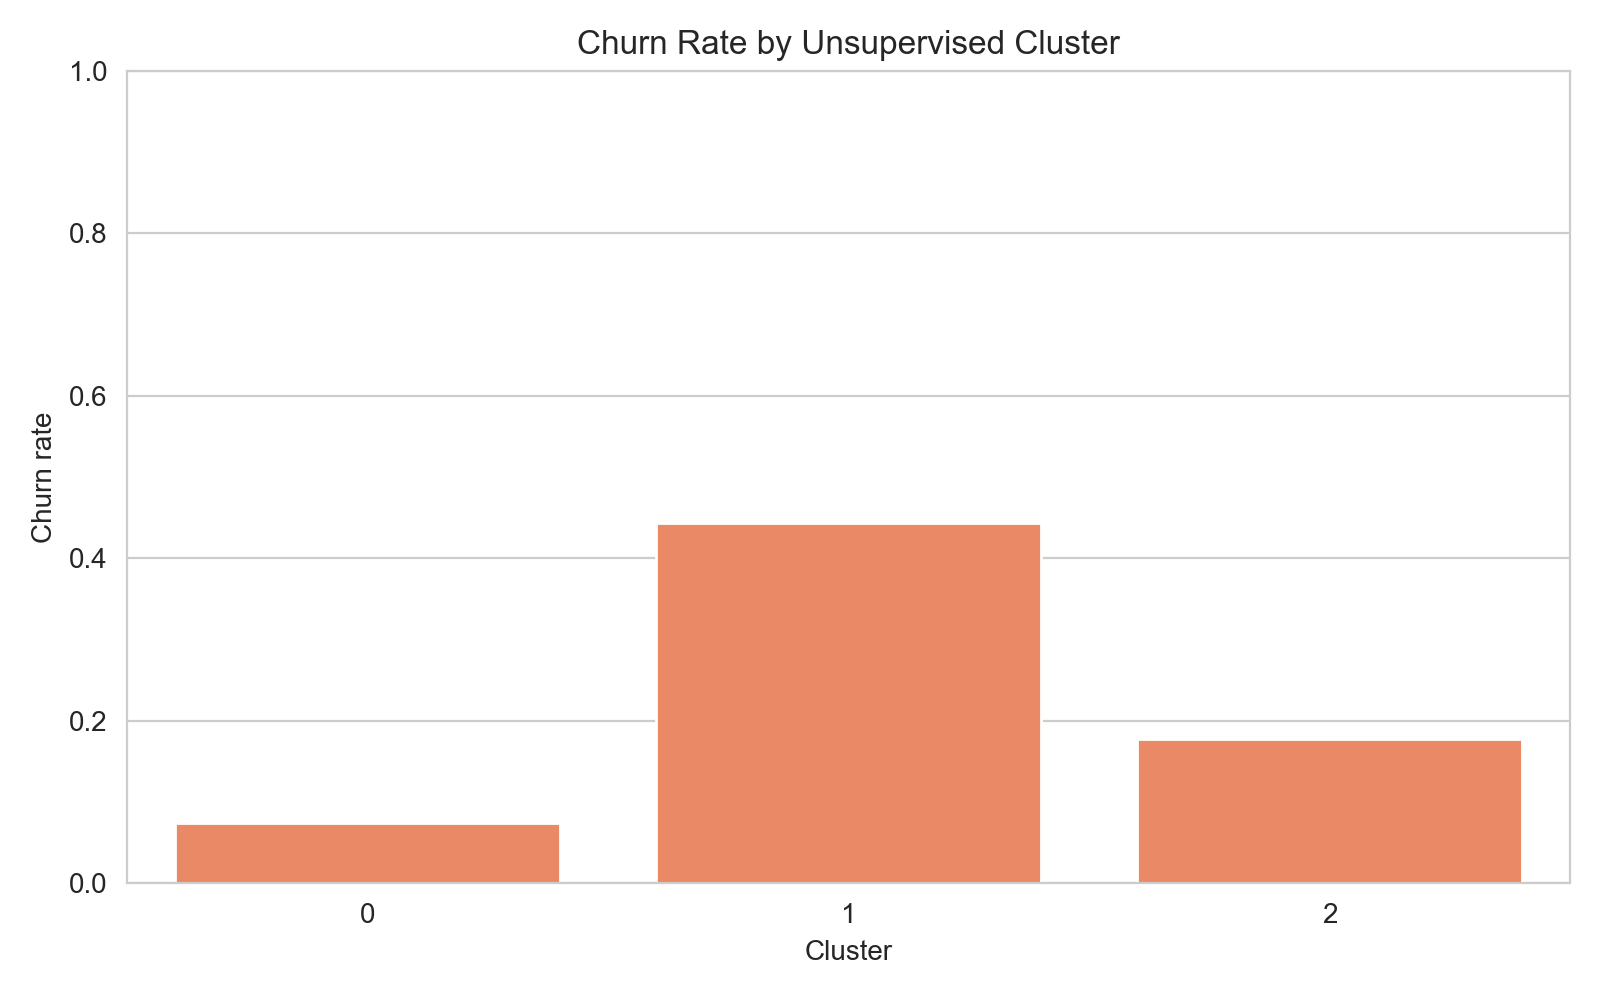


supervised_vs_unsupervised_comparison.png


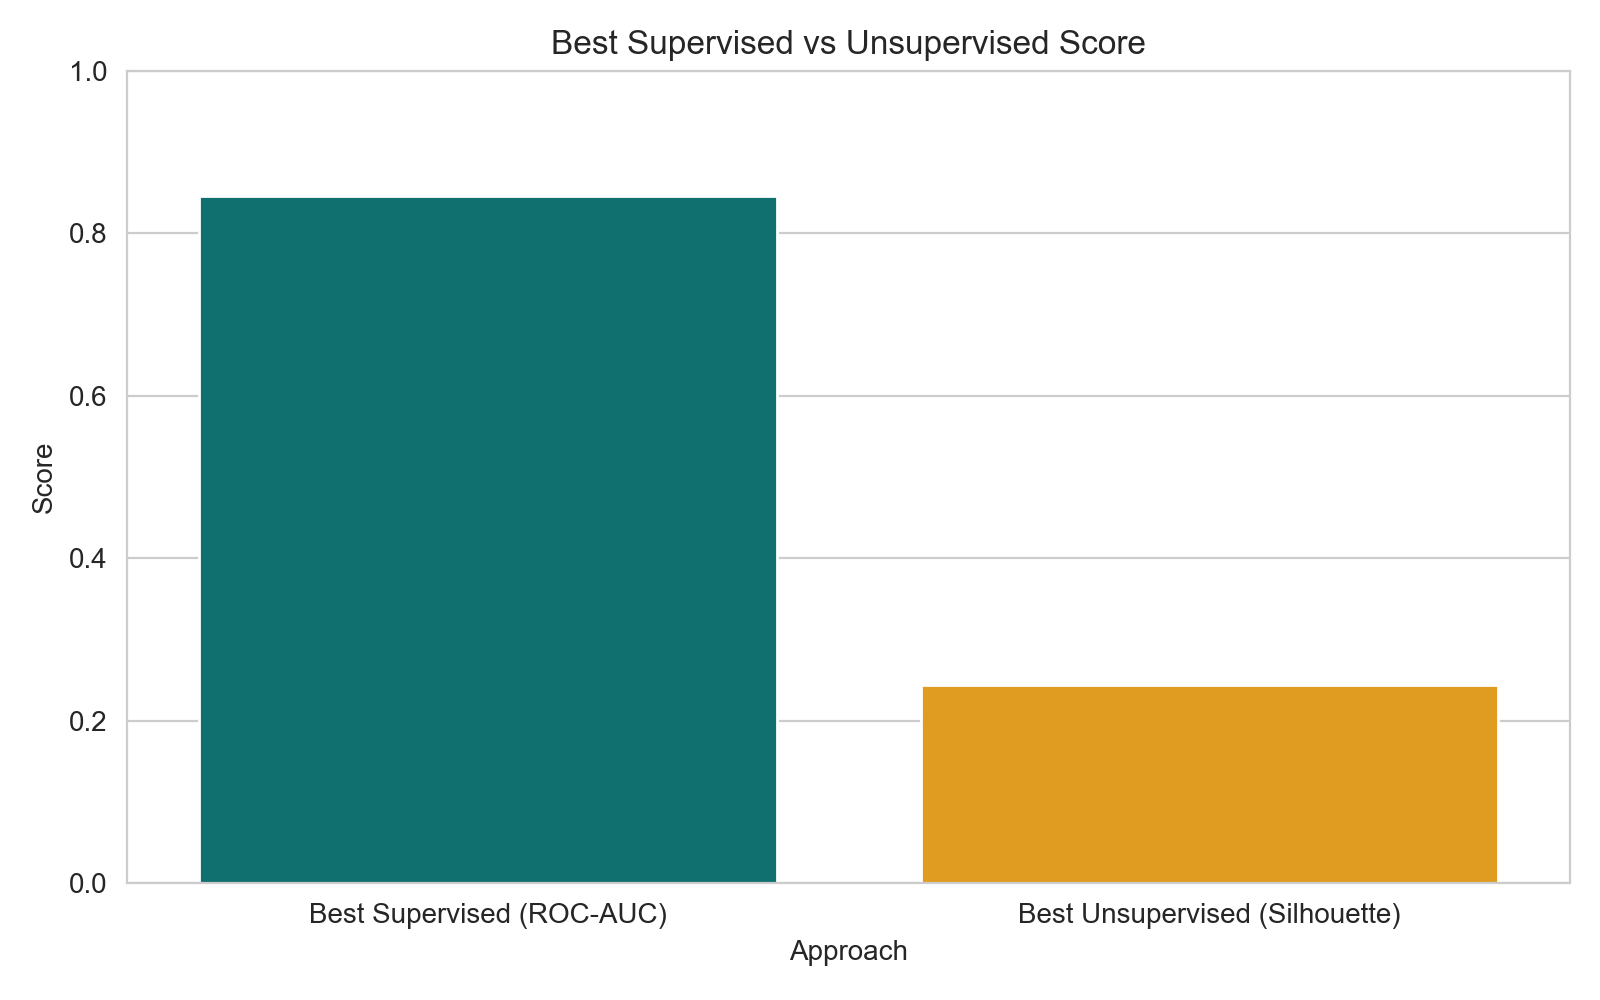

In [10]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

outputs_dir = root / "outputs"
figures_dir = outputs_dir / "figures"

print(f"Project root: {root}")
print(f"Outputs directory exists: {outputs_dir.exists()}")

csv_files = {
    "Supervised model metrics": outputs_dir / "model_comparison.csv",
    "Supervised vs unsupervised": outputs_dir / "supervised_vs_unsupervised_comparison.csv",
    "Unsupervised clustering metrics": outputs_dir / "unsupervised_clustering_metrics.csv",
    "Cluster churn summary": outputs_dir / "unsupervised_cluster_churn_summary.csv",
}

for title, csv_path in csv_files.items():
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        display(df)
    else:
        print(f"Missing file: {csv_path}")

plot_files = [
    "supervised_model_comparison.png",
    "roc_curves_all_models.png",
    "precision_recall_curves_all_models.png",
    "threshold_tuning_f1_comparison.png",
    "confusion_matrix_best_model.png",
    "feature_importance_best_model.png",
    "unsupervised_silhouette_scores.png",
    "unsupervised_elbow_curve.png",
    "unsupervised_clusters_projection.png",
    "unsupervised_cluster_churn_rate.png",
    "supervised_vs_unsupervised_comparison.png",
]

print("\n" + "=" * 80)
print("Plot Gallery")
print("=" * 80)

for file_name in plot_files:
    file_path = figures_dir / file_name
    if file_path.exists():
        print(f"\n{file_name}")
        display(Image(filename=str(file_path)))
    else:
        print(f"Missing plot: {file_name}")